# To-Do Pipeline — Unified Comparison Notebook

Executes every item from `To-do.md` in order, then collects all variants on the same axes so each step's contribution is visible.

**Segment 1 — SOH-aware OCV**
1. Filter the raw SOH series (denoise capacity-fade trace)
2. Estimate SOH from *partial* discharge windows (no need for a full discharge)
3. Build `OCV(SOC, SOH)` so the curve shifts as the cell ages

**Segment 2 — Parameter identification**
4. Inspect how `R0`, `R1`, `C1` are used inside the UKF
5. Estimate them per-cycle from the discharge segment
6. Use the relaxation tail to anchor `V_RC1`
7. LSTM that predicts `(V_RC1_init, R0, R1)` from a short window

**Segment 3 — Robust filter**
8. Augment the UKF state with a current-bias term + adaptive `R` so it is robust to sensor drift / parameter mismatch
9. End-to-end comparison across the four scenarios from Stage 2 (A,B,C,D) on a fresh and an aged cycle, with all four estimators on the same axes.

Train on **B0005**, validate on **B0006**.

_Run cells top-to-bottom._

## 0. Setup

In [1]:
import warnings, os
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.signal import savgol_filter

from utils import (
    Q_NOMINAL_AH, ACTIVE_DISCHARGE_I_A,
    load_metadata, load_cycle, discharge_metadata,
    coulomb_count, BatteryUKF,
    rmse, mae, max_abs_err,
)

plt.rcParams['figure.figsize'] = (10, 4)
plt.rcParams['axes.grid'] = True

TRAIN_BAT = 'B0005'
VAL_BAT   = 'B0006'

disc_train = discharge_metadata(TRAIN_BAT)
disc_val   = discharge_metadata(VAL_BAT)
meta_train = load_metadata(TRAIN_BAT)

def get_cycle(bat, cycle_num):
    """Return (time, current, voltage, soc_truth) for a discharge cycle.
    soc_truth is the Stage-0 Coulomb-counted reference SOC.
    Computed on-the-fly so we don't need a pre-built ground-truth CSV.
    """
    d = discharge_metadata(bat)
    row = d.iloc[cycle_num - 1]
    cyc = load_cycle(bat, row['filename'])
    t = cyc['Time'].to_numpy()
    i = cyc['Current_measured'].to_numpy()
    v = cyc['Voltage_measured'].to_numpy()
    soc_truth = coulomb_count(t, i, soc_init=1.0, q_ah=Q_NOMINAL_AH)
    return t, i, v, soc_truth

print(f'Train: {TRAIN_BAT} - {len(disc_train)} discharge cycles')
print(f'Val:   {VAL_BAT} - {len(disc_val)} discharge cycles')


Train: B0005 - 168 discharge cycles
Val:   B0006 - 168 discharge cycles


## Segment 1 — SOH-aware OCV

### 1.1 Filter the raw SOH trace
Capacity per cycle is noisy (it drops, recovers, drops again). A Savitzky-Golay filter gives a smooth, monotone-ish fade curve usable as ground truth for the SOH estimator.

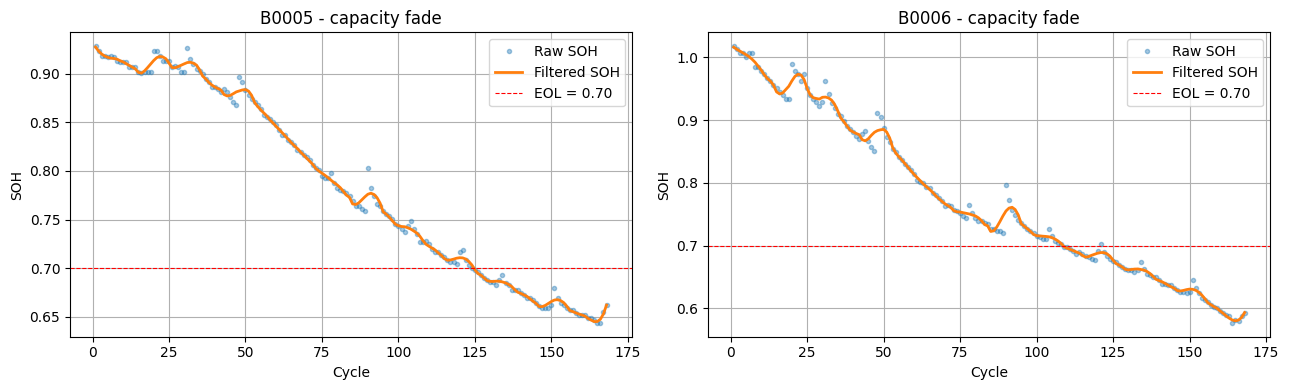

In [2]:
def filter_soh(soh_raw, window=11, polyorder=3):
    w = min(window, len(soh_raw) - (1 - len(soh_raw) % 2))
    if w < polyorder + 2:
        return np.asarray(soh_raw, dtype=float)
    if w % 2 == 0:
        w -= 1
    return savgol_filter(soh_raw, w, polyorder)

disc_train['SOH_filt'] = filter_soh(disc_train['SOH'].values)
disc_val['SOH_filt']   = filter_soh(disc_val['SOH'].values)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, d, name in zip(axes, [disc_train, disc_val], [TRAIN_BAT, VAL_BAT]):
    ax.plot(d['cycle_num'], d['SOH'], 'o', ms=3, alpha=0.4, label='Raw SOH')
    ax.plot(d['cycle_num'], d['SOH_filt'], '-', lw=2, label='Filtered SOH')
    ax.axhline(0.70, color='r', ls='--', lw=0.8, label='EOL = 0.70')
    ax.set_xlabel('Cycle'); ax.set_ylabel('SOH')
    ax.set_title(f'{name} - capacity fade'); ax.legend()
plt.tight_layout(); plt.show()

### 1.2 Estimate SOH from a *partial* discharge window

A short voltage drop $\Delta V$ at constant current contains capacity information. We fit a per-battery linear map
$$ \widehat{\text{SOH}} = a + b\cdot\Delta V_{\text{partial}} $$
from a short fixed-duration segment near the start of each discharge.

Linear fit:  SOH = 1.4368 + -2.2497 * dV_partial
Partial-discharge SOH  RMSE  -- train: 0.0116,  val: 0.0567


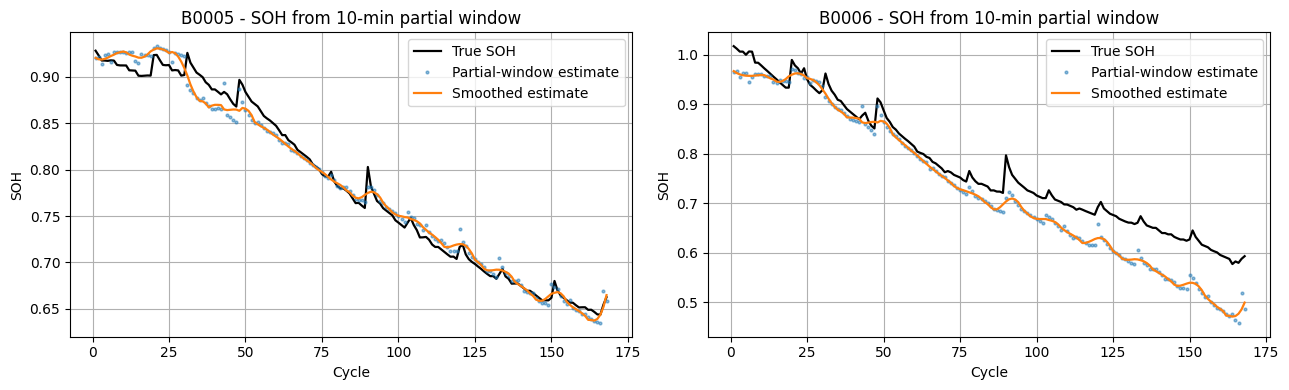

In [3]:
def partial_discharge_features(bat, window_s=600):
    """For each discharge cycle return (cycle_num, dV over first `window_s` of CC, SOH)."""
    d = discharge_metadata(bat)
    rows = []
    for _, row in d.iterrows():
        cyc = load_cycle(bat, row['filename'])
        cc = cyc[cyc['Current_measured'] < ACTIVE_DISCHARGE_I_A].reset_index(drop=True)
        if len(cc) < 5:
            continue
        t0 = cc['Time'].iloc[0]
        win = cc[cc['Time'] - t0 <= window_s]
        if len(win) < 5:
            continue
        dv = win['Voltage_measured'].iloc[0] - win['Voltage_measured'].iloc[-1]
        rows.append({'cycle_num': row['cycle_num'], 'dV_partial': dv, 'SOH': row['SOH']})
    return pd.DataFrame(rows)

feat_train = partial_discharge_features(TRAIN_BAT)
feat_val   = partial_discharge_features(VAL_BAT)

# Linear fit on training data
b, a = np.polyfit(feat_train['dV_partial'], feat_train['SOH'], 1)
feat_train['SOH_partial'] = a + b * feat_train['dV_partial']
feat_val['SOH_partial']   = a + b * feat_val['dV_partial']

# Smooth the partial estimates so they don't whiplash from cycle to cycle
feat_train['SOH_partial_smooth'] = filter_soh(feat_train['SOH_partial'].values)
feat_val['SOH_partial_smooth']   = filter_soh(feat_val['SOH_partial'].values)

rmse_train_p = rmse(feat_train['SOH'], feat_train['SOH_partial_smooth'])
rmse_val_p   = rmse(feat_val['SOH'],   feat_val['SOH_partial_smooth'])
print(f'Linear fit:  SOH = {a:.4f} + {b:.4f} * dV_partial')
print(f'Partial-discharge SOH  RMSE  -- train: {rmse_train_p:.4f},  val: {rmse_val_p:.4f}')

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, df, name in zip(axes, [feat_train, feat_val], [TRAIN_BAT, VAL_BAT]):
    ax.plot(df['cycle_num'], df['SOH'], 'k-', lw=1.6, label='True SOH')
    ax.plot(df['cycle_num'], df['SOH_partial'], '.', ms=4, alpha=0.5, label='Partial-window estimate')
    ax.plot(df['cycle_num'], df['SOH_partial_smooth'], '-', lw=1.6, label='Smoothed estimate')
    ax.set_xlabel('Cycle'); ax.set_ylabel('SOH')
    ax.set_title(f'{name} - SOH from 10-min partial window'); ax.legend()
plt.tight_layout(); plt.show()

### 1.3 Build `OCV(SOC, SOH)` surface

Stage 1_2 used a single OCV polynomial fitted to cycle 1. That's wrong for aged cells — the OCV slope and end-points shift. We fit one polynomial per discharge cycle (using the same `OCV ≈ V - I(R0+R1)` trick) and then interpolate across SOH at run-time.

In [4]:
# Fixed prelim R0,R1 from EIS metadata (reference values only)
imp = meta_train[meta_train['type'] == 'impedance'].dropna(subset=['Re', 'Rct'])
R0_PRIOR = float(imp[imp['test_id'] < 100]['Re'].mean())
R1_PRIOR = float(imp[imp['test_id'] < 100]['Rct'].mean())
C1_PRIOR = 1000.0
print(f'Prior  R0={R0_PRIOR:.4f},  R1={R1_PRIOR:.4f},  C1={C1_PRIOR:.0f},  tau1={R1_PRIOR*C1_PRIOR:.0f}s')

# OCV(SOC, SOH) is represented as a *table* of OCV values on a fixed SOC grid,
# one row per SOH level. Lookup is bilinear (SOC × SOH).
#
# Why not a polynomial? A 5th-order polynomial trained only on the SOC range
# observed during that cycle (e.g. [0.34, 1.0] for an aged cell) extrapolates
# to absurd values when the UKF asks for OCV(SOC=0). The table is clamped at
# the edges of the observed range.

from scipy.interpolate import PchipInterpolator

OCV_SOC_GRID = np.linspace(0.0, 1.0, 51)  # 51 points = 0.02 SOC resolution
soh_grid = None      # populated by build_ocv_surface()
ocv_table = None     # shape (n_soh, len(OCV_SOC_GRID))

def ocv_soh(soc, soh):
    """OCV(SOC, SOH) bilinear lookup. Both inputs are clipped to the table range."""
    soc_c = np.clip(soc, 0.0, 1.0)
    soh_c = np.clip(soh, soh_grid.min(), soh_grid.max())
    # Interpolate each SOC-grid column over SOH, then read at requested SOC.
    row = np.array([np.interp(soh_c, soh_grid, ocv_table[:, k]) for k in range(ocv_table.shape[1])])
    return np.interp(soc_c, OCV_SOC_GRID, row)

def ocv_at_soh(soh):
    return lambda s: ocv_soh(s, soh)

print('Helpers defined; OCV surface will be built after parameter ID.')


Prior  R0=0.0456,  R1=0.0703,  C1=1000,  tau1=70s
Helpers defined; OCV surface will be built after parameter ID.


## Segment 2 — Parameter identification

### 2.1 How R0/R1/C1 enter the UKF (for reference)

From `utils.py`:
$$\text{SOC}_{k+1} = \text{SOC}_k + I_k\,\Delta t / (Q\cdot 3600),\qquad V_{RC1,k+1} = V_{RC1,k}\,e^{-\Delta t/\tau_1} + I_k R_1(1-e^{-\Delta t/\tau_1})$$
$$V_t = \text{OCV}(\text{SOC}) + I R_0 + V_{RC1}$$

* `R0` — instant IR drop. Wrong R0 ⇒ steady DC offset on $V_t$ ⇒ filter compensates with a SOC bias.
* `R1` — drives the polarisation amplitude $I R_1$.
* `C1` — sets the relaxation time-constant $\tau_1 = R_1 C_1$.

### 2.2 Per-cycle estimation of `R0`, `R1`, `C1`

In [5]:
# ---------------------------------------------------------------------------
# Step 2.2(a) — Properly identify the relaxation segment
# ---------------------------------------------------------------------------
# A discharge cycle ends with a long-ish rest. We accept it as a usable
# relaxation segment only if:
#   - the contiguous low-current tail is at least `min_dur_s` long, AND
#   - voltage has nearly settled at the end (|dV/dt| < settle_dvdt_mvs over the
#     last `settle_window_s` seconds)
# Cycles that fail these checks are still usable for parameter fitting via the
# active-discharge phase alone, but their relaxation tail will not be used to
# anchor V_RC1 or the OCV.

def find_relaxation(cycle_df, current_threshold=0.05,
                    min_dur_s=180.0, settle_window_s=60.0,
                    settle_dvdt_mvs=2.0):
    """Return (active_end_idx, relax_df, settled_bool).

    `settled_bool` is True iff the voltage has nearly stopped moving by the end
    of the rest. Use that to decide whether the V_inf from the relaxation fit
    can be trusted as an OCV anchor.
    """
    abs_i = np.abs(cycle_df['Current_measured'].values)
    active_mask = abs_i > current_threshold
    active_idx = np.where(active_mask)[0]
    if len(active_idx) == 0:
        return None, None, False
    end = active_idx[-1]
    relax_df = cycle_df.iloc[end+1:].reset_index(drop=True)
    if len(relax_df) < 5:
        return None, None, False

    t_rel = relax_df['Time'].values - relax_df['Time'].iloc[0]
    if t_rel[-1] < min_dur_s:
        return end, relax_df, False

    last_mask = t_rel >= (t_rel[-1] - settle_window_s)
    if last_mask.sum() < 3:
        return end, relax_df, False
    v_last = relax_df['Voltage_measured'].values[last_mask]
    t_last = t_rel[last_mask]
    dvdt = (v_last[-1] - v_last[0]) / max(t_last[-1] - t_last[0], 1e-3)
    settled = abs(dvdt) * 1000.0 < settle_dvdt_mvs
    return end, relax_df, bool(settled)


# ---------------------------------------------------------------------------
# Step 2.2(b) — Joint R0/R1/C1 fit on the active discharge AND relaxation
# ---------------------------------------------------------------------------
# Two phases, one parameter set:
#   Active CC discharge:  V_t = OCV(SOC) - I_load*R0 - V_RC1(t)
#                         V_RC1(t) -> I_load*R1*(1 - exp(-t/tau1))    (steady current)
#   Relaxation (I=0):     V_t = OCV(SOC_end) + V_RC1_init * exp(-(t-t_off)/tau1)
#
# We solve for (R0, R1, tau1, V_inf) by least squares on the concatenated
# residual. SOC during active discharge is from Coulomb counting on the cycle,
# OCV(SOC) is taken from a *prior* OCV polynomial (we use Stage 1_2's cycle-1
# fit on first pass, then refine after the SOH-indexed OCV exists).

from functools import lru_cache

# Build a one-shot prior OCV from cycle-1 of the train battery using OCV ~ V_relaxed.
# This is a temporary OCV used only inside the parameter-id curve_fit; the proper
# SOH-indexed OCV is built in Section 1.3 below using the same routine's outputs.

def _prior_ocv():
    """Return a 1-D OCV(SOC) callable derived from cycle 1's active discharge with
    a coarse R-correction. Refined later by ocv_at_soh()."""
    cyc = load_cycle(TRAIN_BAT, discharge_metadata(TRAIN_BAT).iloc[0]['filename'])
    t = cyc['Time'].values; i = cyc['Current_measured'].values; v = cyc['Voltage_measured'].values
    soc = coulomb_count(t, i, soc_init=1.0, q_ah=Q_NOMINAL_AH)
    mask = i < ACTIVE_DISCHARGE_I_A
    R_eq = 0.10
    coef = np.polyfit(soc[mask], v[mask] - i[mask] * R_eq, deg=4)
    return lambda s: np.polyval(coef, np.clip(s, 0.0, 1.0))

PRIOR_OCV = _prior_ocv()


def joint_fit_params(t_act, i_act, v_act, soc_act,
                     t_rel, v_rel, ocv_fn=None,
                     R0_init=0.10, R1_init=0.05, tau_init=80.0):
    """Joint LS fit of (R0, R1, tau, V_inf) using both active and relaxation samples.

    `t_rel` is shifted to start at 0. `V_inf` is the asymptotic relaxed voltage
    (≈ OCV(SOC_end)); we fit it explicitly so we don't depend on the prior OCV
    being right at the end SOC.
    """
    if ocv_fn is None:
        ocv_fn = PRIOR_OCV
    # OCV at every active-discharge sample (frozen, since SOC is known there)
    ocv_act = ocv_fn(soc_act)
    # Treat I as a step from t_act[0]: V_RC1(t) = I*R1*(1 - exp(-(t-t0)/tau))
    t_act_rel = t_act - t_act[0]
    n_act = len(t_act); n_rel = len(t_rel)

    def model(_x, R0, R1, tau, V_inf):
        v_pred = np.empty(n_act + n_rel)
        # Active discharge piece
        v_rc_act = i_act * R1 * (1.0 - np.exp(-t_act_rel / tau))
        v_pred[:n_act] = ocv_act + i_act * R0 - v_rc_act  # I_load is negative -> -I*R0 = +|I|*R0 reduction
        # Wait — sign convention: BatteryUKF uses V_t = OCV + I*R0 + V_RC1 with I<0 in discharge.
        # So V_RC1 also tracks sign of I. Use the same convention here:
        v_pred[:n_act] = ocv_act + i_act * R0 + (i_act * R1 * (1.0 - np.exp(-t_act_rel / tau)))
        # Relaxation piece: V(t) = V_inf + V_RC1_at_disconnect * exp(-t/tau)
        # V_RC1_at_disconnect equals the last value from the active-phase formula
        v_rc_at_disc = i_act[-1] * R1 * (1.0 - np.exp(-t_act_rel[-1] / tau))
        v_pred[n_act:] = V_inf + v_rc_at_disc * np.exp(-t_rel / tau)
        return v_pred

    y = np.concatenate([v_act, v_rel])
    try:
        popt, _ = curve_fit(
            model, np.zeros(n_act + n_rel), y,
            p0=[R0_init, R1_init, tau_init, v_rel[-1]],
            bounds=([1e-3, 1e-3, 5.0, 2.0], [0.5, 0.5, 1500.0, 4.5]),
            maxfev=8000,
        )
        R0_h, R1_h, tau_h, V_inf_h = popt
        return float(R0_h), float(R1_h), float(tau_h), float(V_inf_h)
    except Exception:
        return None


def estimate_params_for_cycle(bat, cycle_meta_row):
    cyc = load_cycle(bat, cycle_meta_row['filename'])
    end, relax, settled = find_relaxation(cyc)
    if end is None:
        return None
    active = cyc.iloc[:end+1]
    t_act = active['Time'].values
    i_act = active['Current_measured'].values
    v_act = active['Voltage_measured'].values
    soc_act = coulomb_count(t_act, i_act, soc_init=1.0, q_ah=Q_NOMINAL_AH)
    t_rel = relax['Time'].values - relax['Time'].iloc[0]
    v_rel = relax['Voltage_measured'].values

    fit = joint_fit_params(t_act, i_act, v_act, soc_act, t_rel, v_rel)
    if fit is None:
        return None
    R0_h, R1_h, tau_h, V_inf_h = fit
    C1_h = tau_h / R1_h
    # V_RC1 at the moment the load disconnects — this is what the LSTM should target
    V_RC1_init = i_act[-1] * R1_h * (1.0 - np.exp(-(t_act[-1]-t_act[0]) / tau_h))
    soc_end = soc_act[-1]

    return {
        'cycle_num': cycle_meta_row['cycle_num'],
        'SOH': cycle_meta_row['SOH'],
        'R0': R0_h, 'R1': R1_h, 'C1': C1_h, 'tau': tau_h,
        'V_RC1_init': float(V_RC1_init),
        'V_relaxed': V_inf_h,
        'SOC_end':   float(soc_end),
        'settled':   settled,
    }


params_train = pd.DataFrame([
    p for p in (estimate_params_for_cycle(TRAIN_BAT, r) for _, r in disc_train.iterrows()) if p is not None
])
params_val = pd.DataFrame([
    p for p in (estimate_params_for_cycle(VAL_BAT, r) for _, r in disc_val.iterrows()) if p is not None
])
print(f'Per-cycle params: train={len(params_train)}, val={len(params_val)}')
print(f'  Settled relaxations:  train={params_train.settled.sum()}/{len(params_train)},  '
      f'val={params_val.settled.sum()}/{len(params_val)}')
print(f'  R0  range: [{params_train.R0.min():.4f}, {params_train.R0.max():.4f}]')
print(f'  R1  range: [{params_train.R1.min():.4f}, {params_train.R1.max():.4f}]')
print(f'  tau range: [{params_train.tau.min():.1f}, {params_train.tau.max():.1f}]')
print(f'  V_RC1_init range: [{params_train.V_RC1_init.min():.4f}, {params_train.V_RC1_init.max():.4f}]')
params_train.head()


Per-cycle params: train=168, val=134
  Settled relaxations:  train=124/168,  val=115/134
  R0  range: [0.0010, 0.0856]
  R1  range: [0.0690, 0.2304]
  tau range: [47.8, 1500.0]
  V_RC1_init range: [-0.3661, -0.1216]


,cycle_num,SOH,R0,R1,C1,tau,V_RC1_init,V_relaxed,SOC_end,settled
0,1,0.928244,0.001,0.100333,582.053085,58.399096,-0.201934,3.242525,0.071756,True
1,2,0.923164,0.001,0.098642,634.490810,62.587625,-0.198366,3.256465,0.076836,True
2,3,0.917675,0.001,0.098138,641.589249,62.964557,-0.197558,3.285561,0.082325,True
3,4,0.917631,0.001,0.098294,646.550876,63.551777,-0.197634,3.269890,0.082369,True
4,5,0.917323,0.001,0.098583,656.396972,64.709652,-0.198500,3.258743,0.082677,True


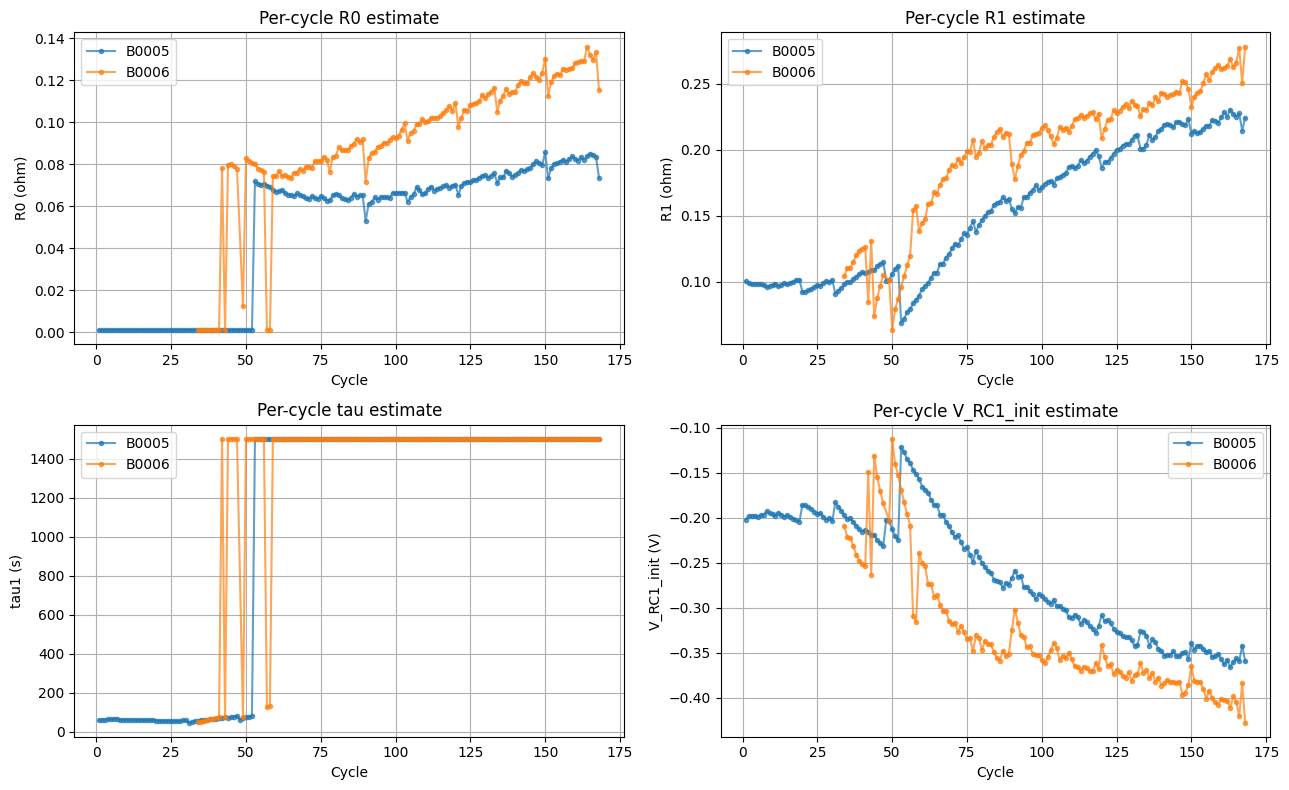

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
for ax, col, ylabel in zip(
    axes.ravel(), ['R0', 'R1', 'tau', 'V_RC1_init'],
    ['R0 (ohm)', 'R1 (ohm)', 'tau1 (s)', 'V_RC1_init (V)']):
    ax.plot(params_train['cycle_num'], params_train[col], '.-', alpha=0.7, label=f'{TRAIN_BAT}')
    ax.plot(params_val['cycle_num'],   params_val[col],   '.-', alpha=0.7, label=f'{VAL_BAT}')
    ax.set_xlabel('Cycle'); ax.set_ylabel(ylabel)
    ax.set_title(f'Per-cycle {col} estimate'); ax.legend()
plt.tight_layout(); plt.show()

OCV table: 168 SOH levels x 51 SOC points
SOH range:  0.644 to 0.928


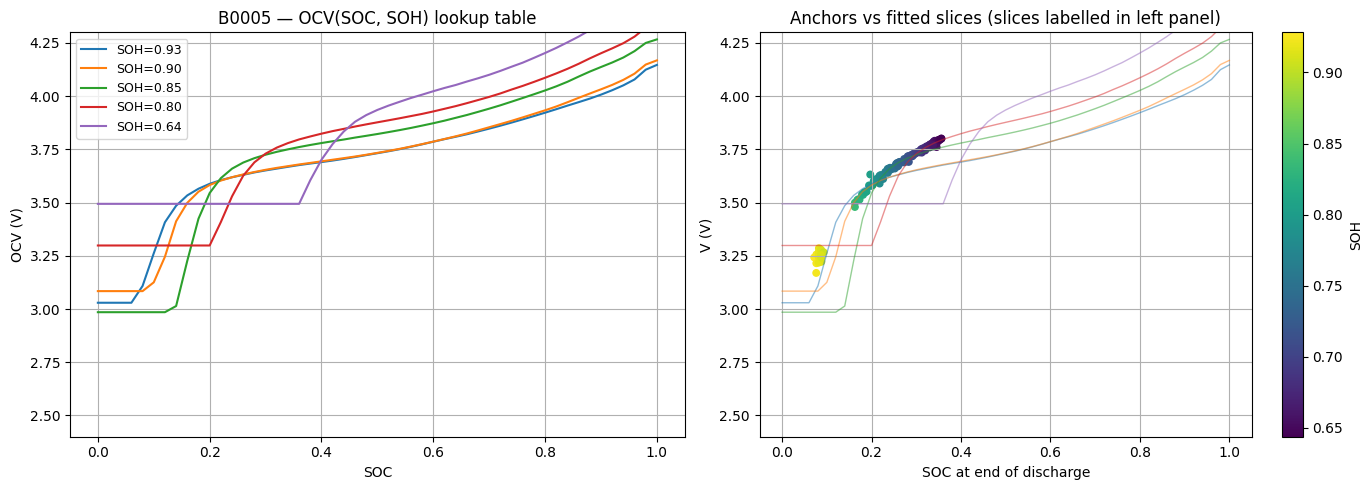

In [7]:
# ---------------------------------------------------------------------------
# Step 1.3 — Build OCV(SOC, SOH) lookup table
# ---------------------------------------------------------------------------
# For each cycle:
#   - Collect anchor points: active-discharge OCV (V - I*R0 - I*R1), the rested
#     V at t=0 (SOC=1), and the post-relaxation V at SOC_end if settled.
#   - Bin the anchors onto the fixed SOC grid (median per bin) so duplicates
#     near SOC_end don't fight each other.
#   - Enforce monotonicity (OCV must rise with SOC) by isotonic-style cleanup.
#   - PCHIP through the cleaned points; clamp outside the observed range.

def _isotonic_increasing(y):
    """Pool-adjacent-violators (lightweight): make `y` non-decreasing in place."""
    y = np.asarray(y, dtype=float).copy()
    n = len(y)
    weights = np.ones(n)
    i = 0
    while i < n - 1:
        if y[i] > y[i+1]:
            # Pool i and i+1
            new_w = weights[i] + weights[i+1]
            new_y = (y[i]*weights[i] + y[i+1]*weights[i+1]) / new_w
            y[i] = new_y; weights[i] = new_w
            y = np.delete(y, i+1); weights = np.delete(weights, i+1)
            n -= 1
            if i > 0: i -= 1
        else:
            i += 1
    return y, weights


def _ocv_curve_for_cycle(bat, cnum, prow):
    cyc = load_cycle(bat, discharge_metadata(bat).iloc[cnum-1]['filename'])
    end, _, settled = find_relaxation(cyc)
    if end is None:
        return None
    active = cyc.iloc[:end+1]
    t = active['Time'].values; i = active['Current_measured'].values
    v = active['Voltage_measured'].values
    soc = coulomb_count(t, i, soc_init=1.0, q_ah=Q_NOMINAL_AH)
    mask = i < ACTIVE_DISCHARGE_I_A
    if mask.sum() < 6:
        return None

    soc_pts = list(soc[mask])
    ocv_pts = list(v[mask] - i[mask] * prow['R0'] - i[mask] * prow['R1'])
    if abs(active['Current_measured'].iloc[0]) < 0.05:
        soc_pts.append(1.0)
        ocv_pts.append(float(active['Voltage_measured'].iloc[0]))
    if settled:
        soc_pts.append(float(prow['SOC_end']))
        ocv_pts.append(float(prow['V_relaxed']))

    soc_pts = np.asarray(soc_pts); ocv_pts = np.asarray(ocv_pts)

    # Bin onto a coarser SOC grid (0.025 res) and take median per bin
    bin_edges = np.arange(0.0, 1.0001, 0.025)
    bin_idx = np.digitize(soc_pts, bin_edges) - 1
    bin_idx = np.clip(bin_idx, 0, len(bin_edges) - 2)
    bin_centers = []; bin_ocv = []
    for b in np.unique(bin_idx):
        sel = bin_idx == b
        bin_centers.append(0.5 * (bin_edges[b] + bin_edges[b+1]))
        bin_ocv.append(float(np.median(ocv_pts[sel])))
    bin_centers = np.asarray(bin_centers); bin_ocv = np.asarray(bin_ocv)

    if len(bin_centers) < 4:
        return None

    # Enforce monotone increasing OCV vs SOC (in case of residual noise)
    order = np.argsort(bin_centers)
    bin_centers = bin_centers[order]; bin_ocv = bin_ocv[order]
    bin_ocv_iso, _ = _isotonic_increasing(bin_ocv)
    # _isotonic_increasing pools points so its length can shrink; rebuild SOC grid to match
    # (each pooled point keeps the centre of the lowest-index member — approximate by averaging x too)
    if len(bin_ocv_iso) != len(bin_centers):
        # Re-pool from scratch keeping x as well
        x = bin_centers.tolist(); y = bin_ocv.tolist()
        i = 0
        while i < len(y) - 1:
            if y[i] > y[i+1]:
                xn = 0.5*(x[i] + x[i+1])
                yn = 0.5*(y[i] + y[i+1])
                x = x[:i] + [xn] + x[i+2:]
                y = y[:i] + [yn] + y[i+2:]
                if i > 0: i -= 1
            else:
                i += 1
        bin_centers = np.asarray(x); bin_ocv_iso = np.asarray(y)

    if len(bin_centers) < 4:
        return None

    smin, smax = float(bin_centers.min()), float(bin_centers.max())
    pchip = PchipInterpolator(bin_centers, bin_ocv_iso, extrapolate=False)
    row = pchip(OCV_SOC_GRID)
    v_lo = float(bin_ocv_iso[0]); v_hi = float(bin_ocv_iso[-1])
    row = np.where(OCV_SOC_GRID < smin, v_lo, row)
    row = np.where(OCV_SOC_GRID > smax, v_hi, row)
    return bin_centers, bin_ocv_iso, smin, smax, row


def build_ocv_surface(bat, params_df):
    p_idx = params_df.set_index('cycle_num')
    soh_list, row_list, range_list = [], [], []
    for cnum in p_idx.index:
        prow = p_idx.loc[cnum]
        out = _ocv_curve_for_cycle(bat, int(cnum), prow)
        if out is None:
            continue
        _, _, smin, smax, row = out
        soh_list.append(float(prow['SOH']))
        row_list.append(row)
        range_list.append((smin, smax))
    order = np.argsort(soh_list)
    return (np.array(soh_list)[order],
            np.array(row_list)[order],
            [range_list[k] for k in order])


soh_grid, ocv_table, soc_ranges = build_ocv_surface(TRAIN_BAT, params_train)
print(f'OCV table: {ocv_table.shape[0]} SOH levels x {ocv_table.shape[1]} SOC points')
print(f'SOH range:  {soh_grid.min():.3f} to {soh_grid.max():.3f}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ax = axes[0]
soh_to_show = [soh_grid.max(), 0.90, 0.85, 0.80, soh_grid.min()]
for soh in soh_to_show:
    ax.plot(OCV_SOC_GRID, ocv_soh(OCV_SOC_GRID, soh), label=f'SOH={soh:.2f}')
ax.set_xlabel('SOC'); ax.set_ylabel('OCV (V)')
ax.set_ylim(2.4, 4.3)
ax.set_title(f'{TRAIN_BAT} — OCV(SOC, SOH) lookup table')
ax.legend(fontsize=9)

ax = axes[1]
settled_pts = params_train[params_train['settled']]
sc = ax.scatter(settled_pts['SOC_end'], settled_pts['V_relaxed'],
                c=settled_pts['SOH'], cmap='viridis', s=22, label='Relaxed-V anchors')
plt.colorbar(sc, ax=ax, label='SOH')
for soh in soh_to_show:
    ax.plot(OCV_SOC_GRID, ocv_soh(OCV_SOC_GRID, soh), '-', alpha=0.5, lw=1)
ax.set_xlabel('SOC at end of discharge'); ax.set_ylabel('V (V)')
ax.set_title('Anchors vs fitted slices (slices labelled in left panel)')
ax.set_ylim(2.4, 4.3)
plt.tight_layout(); plt.show()


### 1.4 — Global OCV(SOC) pooled across all 11 batteries

OCV is an intrinsic chemistry property, so it should be the *same* curve for every cell. We:

1. Loop over **all 11 batteries** in `room_temp_batteries/`.
2. For each discharge cycle, extract two clean OCV anchors:
   - **Top anchor**: rested terminal voltage at `t=0` (well-rested before discharge starts) → `(SOC=1, V[0])`.
   - **Bottom anchor**: post-relaxation voltage `V_relaxed` at `SOC_end`, only when relaxation is settled (long enough rest, `|dV/dt| < 2 mV/s`).
3. Add **steady-state discharge anchors**: `V_t + |I|*R_eq` for each active-discharge sample, where `R_eq` is fitted *per cycle* as the constant vertical shift between the active-discharge curve and the OCV backbone built from the rest anchors.
4. Pool, bin, and PCHIP through everything to get one global OCV(SOC).

Aging then lives entirely in **`R_eq` vs SOH**, plotted below.

  2174 rest anchors  (1339 top, 835 bottom)
Coarse OCV (rest only): 10 knots, SOC coverage [0.07, 0.99]
Fitting per-cycle R_eq using coarse OCV (anchored region only)...


  Used SOC <= 0.353, got 1185 cycles, R_eq range [0.090, 0.434]
Pooling active-discharge anchors (V + I*R_eq)...


  Total anchors now: 61934 (2174 rest + 59760 active)
Refined global OCV: 48 knots, SOC coverage [0.01, 0.99]


Refined R_eq: 1339 cycles, range [0.049, 0.418]


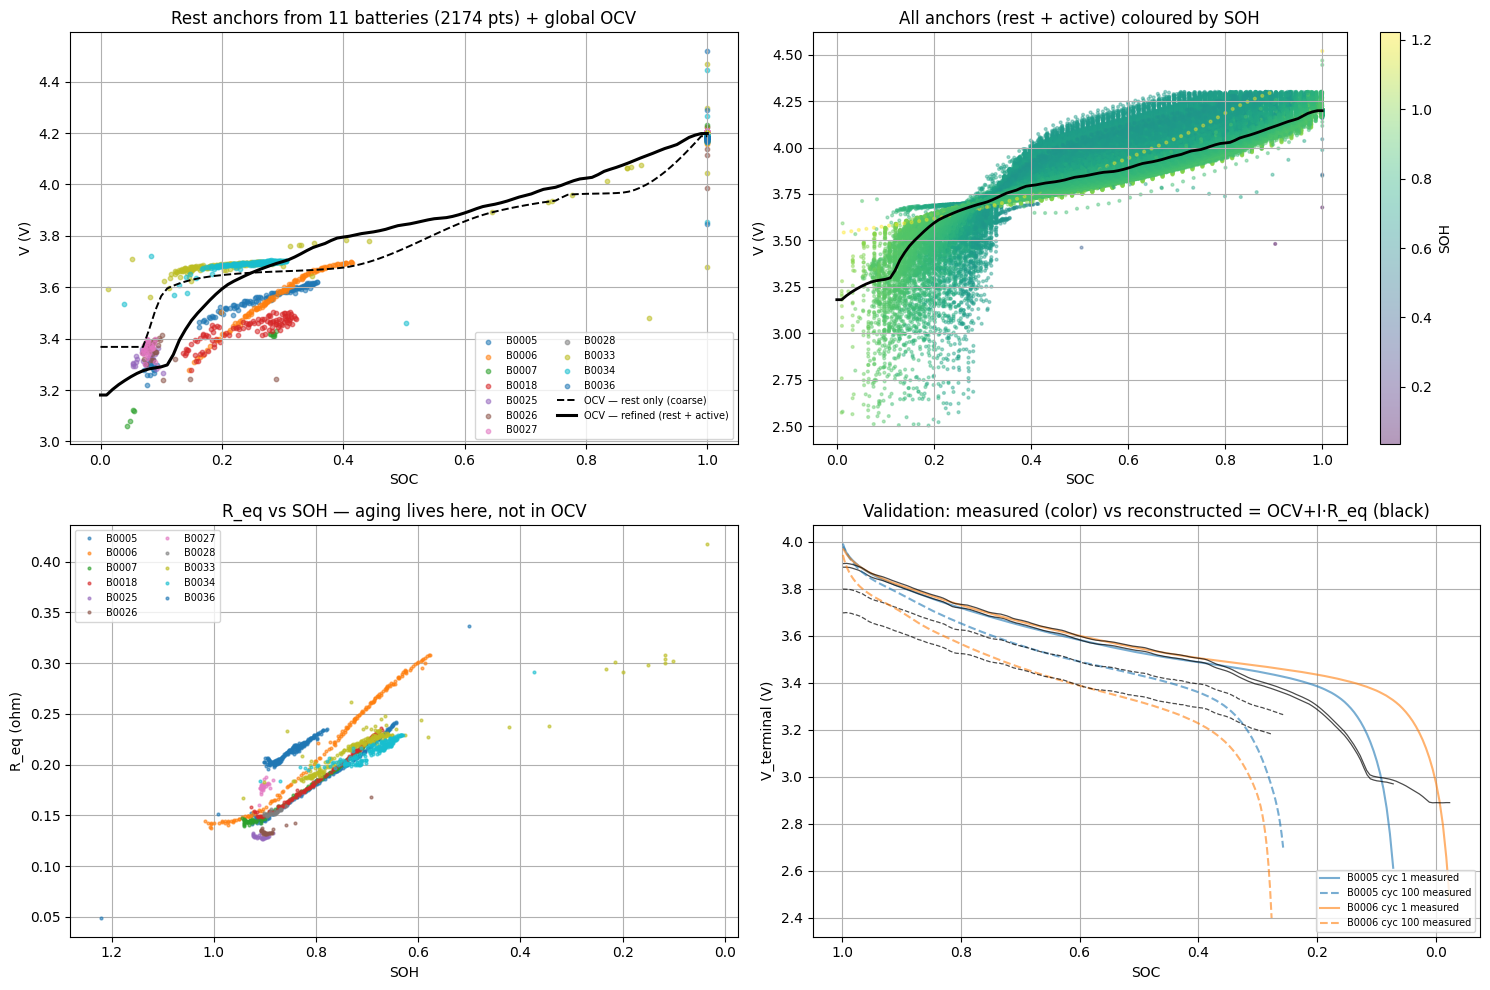


V-reconstruction RMSE (active discharge phase) per battery — refined OCV:
battery  V_RMSE_mean  V_RMSE_p95
  B0005       0.0872      0.1255
  B0006       0.1096      0.1405
  B0007       0.1213      0.1590
  B0018       0.1049      0.1428
  B0025       0.1033      0.1224
  B0026       0.0894      0.1032
  B0027       0.0573      0.0648
  B0028       0.0485      0.0535
  B0033       0.1403      0.2092
  B0034       0.1245      0.1447
  B0036       0.0537      0.0752


In [8]:
ALL_BATTERIES = ['B0005', 'B0006', 'B0007', 'B0018',
                 'B0025', 'B0026', 'B0027', 'B0028',
                 'B0033', 'B0034', 'B0036']

# ---------------------------------------------------------------------------
# Step 1 — Pool the *clean* rest anchors from every cycle of every battery.
# Two anchor types per discharge cycle:
#   - top:    rested terminal V at t=0       -> (SOC=1, V[0])
#   - bottom: settled post-discharge V       -> (SOC_end, V_relaxed)
# ---------------------------------------------------------------------------

def collect_rest_anchors():
    rows = []
    for bat in ALL_BATTERIES:
        try:
            d = discharge_metadata(bat)
        except Exception as e:
            print(f'  skip {bat}: {e}'); continue
        for _, mrow in d.iterrows():
            cyc = load_cycle(bat, mrow['filename'])
            t = cyc['Time'].values; i = cyc['Current_measured'].values
            v = cyc['Voltage_measured'].values
            if abs(i[0]) < 0.05:
                rows.append({'battery': bat, 'cycle': int(mrow['cycle_num']),
                             'SOH': float(mrow['SOH']),
                             'kind': 'top', 'soc': 1.0, 'v': float(v[0])})
            end, relax, settled = find_relaxation(cyc)
            if end is None or not settled:
                continue
            soc = coulomb_count(t, i, soc_init=1.0, q_ah=2.0)
            soc_end = float(soc[end])
            v_relaxed = float(relax['Voltage_measured'].iloc[-1])
            if 0.0 <= soc_end <= 1.05 and 2.0 <= v_relaxed <= 4.5:
                rows.append({'battery': bat, 'cycle': int(mrow['cycle_num']),
                             'SOH': float(mrow['SOH']),
                             'kind': 'bottom', 'soc': soc_end, 'v': v_relaxed})
    return pd.DataFrame(rows)

print('Collecting rest anchors across 11 batteries...')
anchors_rest = collect_rest_anchors()
print(f'  {len(anchors_rest)} rest anchors  ({(anchors_rest.kind=="top").sum()} top, '
      f'{(anchors_rest.kind=="bottom").sum()} bottom)')


# ---------------------------------------------------------------------------
# Step 2 — Fit a coarse OCV from rest anchors only (covers SOC≈[0.05,0.35] U {1.0})
# ---------------------------------------------------------------------------
def fit_pchip(anchor_df, bin_size=0.02):
    soc = anchor_df['soc'].to_numpy(); v = anchor_df['v'].to_numpy()
    edges = np.arange(0.0, 1.0001, bin_size)
    idx = np.clip(np.digitize(soc, edges) - 1, 0, len(edges) - 2)
    centres, vals = [], []
    for b in np.unique(idx):
        sel = idx == b
        if sel.sum() < 1: continue
        centres.append(0.5 * (edges[b] + edges[b+1]))
        vals.append(float(np.median(v[sel])))
    centres = np.asarray(centres); vals = np.asarray(vals)
    order = np.argsort(centres); centres = centres[order]; vals = vals[order]
    # isotonic (pool adjacent violators, light)
    x = centres.tolist(); y = vals.tolist(); i = 0
    while i < len(y) - 1:
        if y[i] > y[i+1]:
            x = x[:i] + [0.5*(x[i]+x[i+1])] + x[i+2:]
            y = y[:i] + [0.5*(y[i]+y[i+1])] + y[i+2:]
            if i > 0: i -= 1
        else:
            i += 1
    centres = np.asarray(x); vals = np.asarray(y)
    return centres, vals, PchipInterpolator(centres, vals, extrapolate=False)


SOC_GRID_GLOBAL = np.linspace(0.0, 1.0, 101)

def build_ocv(soc_ctrl, ocv_ctrl, pchip):
    v_lo, v_hi = float(ocv_ctrl[0]), float(ocv_ctrl[-1])
    smin, smax = float(soc_ctrl[0]), float(soc_ctrl[-1])
    def ocv(soc):
        s = np.clip(soc, 0.0, 1.0)
        out = pchip(s)
        out = np.where(s < smin, v_lo, out)
        out = np.where(s > smax, v_hi, out)
        return out
    return ocv

soc_c0, ocv_c0, pchip0 = fit_pchip(anchors_rest)
ocv_v0 = build_ocv(soc_c0, ocv_c0, pchip0)
print(f'Coarse OCV (rest only): {len(soc_c0)} knots, SOC coverage [{soc_c0.min():.2f}, {soc_c0.max():.2f}]')


# ---------------------------------------------------------------------------
# Step 3 — Per-cycle R_eq using the coarse OCV (only on samples whose SOC lies
# inside the rest-anchor coverage; we don't trust extrapolated OCV here).
# ---------------------------------------------------------------------------
def fit_R_eq(ocv_fn, soc_ok_lo, soc_ok_hi):
    rows = []
    for bat in ALL_BATTERIES:
        d = discharge_metadata(bat)
        for _, mrow in d.iterrows():
            cyc = load_cycle(bat, mrow['filename'])
            t = cyc['Time'].values; i = cyc['Current_measured'].values
            v = cyc['Voltage_measured'].values
            soc = coulomb_count(t, i, soc_init=1.0, q_ah=2.0)
            mask = (i < ACTIVE_DISCHARGE_I_A) & (soc >= soc_ok_lo) & (soc <= soc_ok_hi)
            if mask.sum() < 10: continue
            r = (ocv_fn(soc[mask]) - v[mask]) / (-i[mask])
            r_med = float(np.median(r))
            if 1e-3 < r_med < 1.0:
                rows.append({'battery': bat, 'cycle': int(mrow['cycle_num']),
                             'SOH': float(mrow['SOH']), 'R_eq': r_med})
    return pd.DataFrame(rows)

# Use only SOC samples covered by rest anchors for the first R_eq fit
print('Fitting per-cycle R_eq using coarse OCV (anchored region only)...')
soc_lo_anchor = float(anchors_rest[anchors_rest.kind=='bottom']['soc'].quantile(0.95))
r_eq_df = fit_R_eq(ocv_v0, 0.0, soc_lo_anchor)
print(f'  Used SOC <= {soc_lo_anchor:.3f}, got {len(r_eq_df)} cycles, R_eq range [{r_eq_df.R_eq.min():.3f}, {r_eq_df.R_eq.max():.3f}]')


# ---------------------------------------------------------------------------
# Step 4 — Bootstrap: now that we have R_eq per cycle, derive mid-range OCV
# anchors from the active discharge: OCV = V_t - I*R_eq. Pool with rest anchors.
# ---------------------------------------------------------------------------
def collect_active_anchors(r_eq_df, stride=4):
    r_idx = r_eq_df.set_index(['battery', 'cycle'])
    rows = []
    for bat in ALL_BATTERIES:
        d = discharge_metadata(bat)
        for _, mrow in d.iterrows():
            key = (bat, int(mrow['cycle_num']))
            if key not in r_idx.index: continue
            r_eq = float(r_idx.loc[key]['R_eq'])
            cyc = load_cycle(bat, mrow['filename'])
            t = cyc['Time'].values; i = cyc['Current_measured'].values
            v = cyc['Voltage_measured'].values
            soc = coulomb_count(t, i, soc_init=1.0, q_ah=2.0)
            mask = i < ACTIVE_DISCHARGE_I_A
            idx = np.where(mask)[0][::stride]
            for k in idx:
                ocv_k = v[k] - i[k] * r_eq
                if 2.5 <= ocv_k <= 4.3 and 0.0 <= soc[k] <= 1.05:
                    rows.append({'battery': bat, 'cycle': key[1],
                                 'SOH': float(mrow['SOH']),
                                 'kind': 'active', 'soc': float(soc[k]),
                                 'v': float(ocv_k)})
    return pd.DataFrame(rows)

print('Pooling active-discharge anchors (V + I*R_eq)...')
anchors_active = collect_active_anchors(r_eq_df)
anchors_all = pd.concat([anchors_rest, anchors_active], ignore_index=True)
print(f'  Total anchors now: {len(anchors_all)} ({len(anchors_rest)} rest + {len(anchors_active)} active)')

soc_c1, ocv_c1, pchip1 = fit_pchip(anchors_all)
ocv_global = build_ocv(soc_c1, ocv_c1, pchip1)
print(f'Refined global OCV: {len(soc_c1)} knots, SOC coverage [{soc_c1.min():.2f}, {soc_c1.max():.2f}]')

# Final R_eq using the refined OCV across the *full* SOC range
r_eq_df = fit_R_eq(ocv_global, 0.0, 1.0)
print(f'Refined R_eq: {len(r_eq_df)} cycles, range [{r_eq_df.R_eq.min():.3f}, {r_eq_df.R_eq.max():.3f}]')


# ---------------------------------------------------------------------------
# Step 5 — Plots
# ---------------------------------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

ax = axes[0, 0]
for bat, grp in anchors_rest.groupby('battery'):
    ax.scatter(grp['soc'], grp['v'], s=10, alpha=0.55, label=bat)
ax.plot(SOC_GRID_GLOBAL, ocv_v0(SOC_GRID_GLOBAL),  'k--', lw=1.4, label='OCV — rest only (coarse)')
ax.plot(SOC_GRID_GLOBAL, ocv_global(SOC_GRID_GLOBAL), 'k-',  lw=2.2, label='OCV — refined (rest + active)')
ax.set_xlabel('SOC'); ax.set_ylabel('V (V)')
ax.set_title(f'Rest anchors from 11 batteries ({len(anchors_rest)} pts) + global OCV')
ax.legend(fontsize=7, loc='lower right', ncol=2)

ax = axes[0, 1]
sc = ax.scatter(anchors_all['soc'], anchors_all['v'], c=anchors_all['SOH'],
                cmap='viridis', s=4, alpha=0.4)
plt.colorbar(sc, ax=ax, label='SOH')
ax.plot(SOC_GRID_GLOBAL, ocv_global(SOC_GRID_GLOBAL), 'k-', lw=2)
ax.set_xlabel('SOC'); ax.set_ylabel('V (V)')
ax.set_title('All anchors (rest + active) coloured by SOH')

ax = axes[1, 0]
for bat, grp in r_eq_df.groupby('battery'):
    ax.plot(grp['SOH'], grp['R_eq'], '.', ms=4, alpha=0.6, label=bat)
ax.set_xlabel('SOH'); ax.set_ylabel('R_eq (ohm)')
ax.set_title('R_eq vs SOH — aging lives here, not in OCV')
ax.legend(fontsize=7, ncol=2); ax.invert_xaxis()

ax = axes[1, 1]
for bat, color in [('B0005', 'tab:blue'), ('B0006', 'tab:orange')]:
    d = discharge_metadata(bat)
    for cn, ls in [(1, '-'), (100, '--')]:
        if cn > len(d): continue
        m = r_eq_df[(r_eq_df.battery == bat) & (r_eq_df.cycle == cn)]
        if m.empty: continue
        r_eq = float(m.iloc[0]['R_eq'])
        cyc = load_cycle(bat, d.iloc[cn-1]['filename'])
        t = cyc['Time'].values; i = cyc['Current_measured'].values; v = cyc['Voltage_measured'].values
        soc = coulomb_count(t, i, soc_init=1.0, q_ah=2.0)
        v_pred = ocv_global(soc) + i * r_eq
        mask = i < ACTIVE_DISCHARGE_I_A
        ax.plot(soc[mask], v[mask],      ls, color=color, alpha=0.6, label=f'{bat} cyc {cn} measured')
        ax.plot(soc[mask], v_pred[mask], ls, color='k', alpha=0.7, lw=0.9)
ax.set_xlabel('SOC'); ax.set_ylabel('V_terminal (V)')
ax.set_title('Validation: measured (color) vs reconstructed = OCV+I·R_eq (black)')
ax.legend(fontsize=7, loc='lower right'); ax.invert_xaxis()

plt.tight_layout(); plt.show()


# Numeric validation
val_rows = []
for bat in ALL_BATTERIES:
    d = discharge_metadata(bat)
    errs = []
    for _, mrow in d.iterrows():
        m = r_eq_df[(r_eq_df.battery == bat) & (r_eq_df.cycle == int(mrow['cycle_num']))]
        if m.empty: continue
        r_eq = float(m.iloc[0]['R_eq'])
        cyc = load_cycle(bat, mrow['filename'])
        t = cyc['Time'].values; i = cyc['Current_measured'].values; v = cyc['Voltage_measured'].values
        soc = coulomb_count(t, i, soc_init=1.0, q_ah=2.0)
        mask = i < ACTIVE_DISCHARGE_I_A
        if mask.sum() < 10: continue
        v_pred = ocv_global(soc[mask]) + i[mask] * r_eq
        errs.append(rmse(v[mask], v_pred))
    if errs:
        val_rows.append({'battery': bat, 'V_RMSE_mean': float(np.mean(errs)),
                         'V_RMSE_p95': float(np.percentile(errs, 95))})
print()
print('V-reconstruction RMSE (active discharge phase) per battery — refined OCV:')
print(pd.DataFrame(val_rows).round(4).to_string(index=False))


### 2.3 LSTM that predicts (V_RC1_init, R0, R1)

Same window structure as the existing Stage 3 notebook, but extended to a 3-output regressor.

In [9]:
import subprocess, sys
try:
    import tensorflow as tf
    from tensorflow import keras
    from tensorflow.keras import layers
except ImportError:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'tensorflow', '-q'])
    import tensorflow as tf
    from tensorflow import keras
    from tensorflow.keras import layers
tf.random.set_seed(0); np.random.seed(0)
print('TF', tf.__version__)

TF 2.21.0


In [10]:
WINDOW = 30
STRIDE = 5

def build_dataset(bat, params_df):
    """For each cycle that has parameter estimates, slide a window over the active
    discharge phase and emit (V, I, dt, SOC_cc) -> (V_RC1_init, R0, R1).
    """
    d = discharge_metadata(bat)
    p_index = params_df.set_index('cycle_num')
    X_list, y_list, soh_list = [], [], []
    for _, row in d.iterrows():
        if row['cycle_num'] not in p_index.index:
            continue
        cyc = load_cycle(bat, row['filename'])
        end, _, _ = find_relaxation(cyc)
        if end is None or end < WINDOW:
            continue
        active = cyc.iloc[:end+1].copy()
        t = active['Time'].values
        i = active['Current_measured'].values
        v = active['Voltage_measured'].values
        soc_cc = coulomb_count(t, i, soc_init=1.0, q_ah=Q_NOMINAL_AH)
        targets = p_index.loc[row['cycle_num']]
        for s in range(0, len(active) - WINDOW, STRIDE):
            win = slice(s, s + WINDOW)
            X_list.append(np.column_stack([
                v[win], i[win], t[win] - t[s], soc_cc[win],
            ]))
            y_list.append([targets['V_RC1_init'], targets['R0'], targets['R1']])
            soh_list.append(targets['SOH'])
    return np.asarray(X_list), np.asarray(y_list), np.asarray(soh_list)

X_tr, y_tr, soh_tr = build_dataset(TRAIN_BAT, params_train)
X_va, y_va, soh_va = build_dataset(VAL_BAT,   params_val)
print(f'X_tr={X_tr.shape}  y_tr={y_tr.shape}  X_va={X_va.shape}  y_va={y_va.shape}')

# Per-feature standardisation using train statistics
x_mean = X_tr.mean(axis=(0,1), keepdims=True)
x_std  = X_tr.std (axis=(0,1), keepdims=True) + 1e-9
y_mean = y_tr.mean(axis=0, keepdims=True)
y_std  = y_tr.std (axis=0, keepdims=True) + 1e-9
Xn_tr = (X_tr - x_mean) / x_std
Xn_va = (X_va - x_mean) / x_std
yn_tr = (y_tr - y_mean) / y_std
yn_va = (y_va - y_mean) / y_std

X_tr=(8148, 30, 4)  y_tr=(8148, 3)  X_va=(6775, 30, 4)  y_va=(6775, 3)

In [11]:
model = keras.Sequential([
    layers.Input(shape=(WINDOW, 4)),
    layers.LSTM(48, return_sequences=True),
    layers.Dropout(0.2),
    layers.LSTM(24),
    layers.Dropout(0.2),
    layers.Dense(16, activation='relu'),
    layers.Dense(3),
])
model.compile(optimizer=keras.optimizers.Adam(1e-3), loss='mse', metrics=['mae'])
history = model.fit(Xn_tr, yn_tr, validation_data=(Xn_va, yn_va),
                    epochs=40, batch_size=64, verbose=0)
print('Train MSE:', history.history['loss'][-1], '  Val MSE:', history.history['val_loss'][-1])

Train MSE: 0.054440174251794815   Val MSE: 0.4736038148403168


In [12]:
def predict_params(bat, cycle_num):
    """Average LSTM (V_RC1, R0, R1) predictions over all windows in a cycle."""
    cyc = load_cycle(bat, discharge_metadata(bat).iloc[cycle_num-1]['filename'])
    end, _, _ = find_relaxation(cyc)
    active = cyc.iloc[:(end+1) if end else len(cyc)].copy()
    t = active['Time'].values; i = active['Current_measured'].values
    v = active['Voltage_measured'].values
    soc_cc = coulomb_count(t, i, soc_init=1.0, q_ah=Q_NOMINAL_AH)
    Xs = []
    for s in range(0, max(1, len(active) - WINDOW), STRIDE):
        win = slice(s, s + WINDOW)
        if win.stop > len(active):
            break
        Xs.append(np.column_stack([v[win], i[win], t[win]-t[s], soc_cc[win]]))
    if len(Xs) == 0:
        # Fallback: not enough samples for a window; return per-cycle means as a safe default
        return float(y_mean[0, 0]), float(max(y_mean[0, 1], 1e-4)), float(max(y_mean[0, 2], 1e-4))
    Xs = (np.asarray(Xs) - x_mean) / x_std
    pred_n = model.predict(Xs, verbose=0)
    pred = pred_n * y_std + y_mean
    v_rc1, r0, r1 = pred.mean(axis=0)
    return float(v_rc1), float(max(r0, 1e-4)), float(max(r1, 1e-4))

# Sanity check on a few cycles that have ground-truth parameter fits
val_cycles_with_truth = set(params_val['cycle_num'].astype(int).tolist())
sample_for_check = [c for c in [1, 50, 100, 150] if c in val_cycles_with_truth][:3]
for c in sample_for_check:
    vrc, r0, r1 = predict_params(VAL_BAT, c)
    truth = params_val[params_val['cycle_num'] == c].iloc[0]
    print(f'{VAL_BAT} cyc {c:3d}  pred (V_RC1,R0,R1) = ({vrc:+.4f},{r0:.4f},{r1:.4f})  '
          f'true ({truth.V_RC1_init:+.4f},{truth.R0:.4f},{truth.R1:.4f})')


B0006 cyc  50  pred (V_RC1,R0,R1) = (-0.1763,0.0618,0.0998)  true (-0.1123,0.0828,0.0633)
B0006 cyc 100  pred (V_RC1,R0,R1) = (-0.3412,0.0766,0.2110)  true (-0.3580,0.0927,0.2163)
B0006 cyc 150  pred (V_RC1,R0,R1) = (-0.3557,0.0812,0.2218)  true (-0.3649,0.1302,0.2326)


## Final comparison — estimators on the same scenarios

**Estimators**
* **CC** — pure Coulomb counting (open-loop baseline)
* **UKF-base** — Stage 1_2: cycle-1 polynomial OCV, fixed `R0/R1/C1`, 2-state
* **UKF-Seg1** — SOH-indexed OCV (this notebook), fixed `R0/R1/C1`, 2-state
* **UKF-Seg2** — SOH-indexed OCV + LSTM-predicted `R0/R1` and `V_RC1_init`, 2-state

**Scenarios** (matches Stage 1_2):
| | SOC0 | bias |
|---|---|---|
| A | 1.00 | 0 |
| B | 0.50 | 0 |
| C | 1.00 | +50 mA |
| D | 0.85 | +10 mA |

(Segment 3 — robust UKF with bias state — is parked while we get Segments 1 & 2 right.)

In [13]:
# Stage 1_2 baseline OCV: cycle-1 polynomial of B0005 (no SOH dependence)
_cyc1 = load_cycle(TRAIN_BAT, discharge_metadata(TRAIN_BAT).iloc[0]['filename'])
_t1 = _cyc1['Time'].values; _i1 = _cyc1['Current_measured'].values; _v1 = _cyc1['Voltage_measured'].values
_soc1 = coulomb_count(_t1, _i1, soc_init=1.0, q_ah=Q_NOMINAL_AH)
_mask1 = _i1 < ACTIVE_DISCHARGE_I_A
OCV_BASE_COEF = np.polyfit(_soc1[_mask1], _v1[_mask1] - _i1[_mask1] * (R0_PRIOR + R1_PRIOR), deg=5)
ocv_base = lambda s: np.polyval(OCV_BASE_COEF, np.clip(s, 0, 1))

P0_TIGHT_2 = np.diag([1e-4, 1e-4])
P0_LOOSE_2 = np.diag([0.25,  1e-2])
Q_PROC_2   = np.diag([1e-7, 1e-6])
R_MEAS     = 5e-3

scenarios = [
    ('A. Best case',           1.00, 0.000),
    ('B. SOC0 off by 50%',     0.50, 0.000),
    ('C. +50 mA bias',         1.00, 0.050),
    ('D. SOC0=0.85 + 10 mA',   0.85, 0.010),
]

def run_all_estimators(bat, cycle_num, soh_for_seg1):
    t, i, v, truth = get_cycle(bat, cycle_num)
    v_rc1_p, r0_p, r1_p = predict_params(bat, cycle_num)
    c1_p = max(50.0, R1_PRIOR * C1_PRIOR / r1_p)

    out = {'t': t, 'truth': truth, 'meta': {
        'cycle': cycle_num, 'soh': soh_for_seg1,
        'lstm_v_rc1': v_rc1_p, 'lstm_R0': r0_p, 'lstm_R1': r1_p,
    }, 'scenarios': {}}
    for name, s0, bias in scenarios:
        ie = i + bias
        soc_cc = coulomb_count(t, ie, soc_init=s0, q_ah=Q_NOMINAL_AH)
        ukf_base = BatteryUKF(ocv_base,             R0_PRIOR, R1_PRIOR, C1_PRIOR)
        ukf_s1   = BatteryUKF(ocv_at_soh(soh_for_seg1), R0_PRIOR, R1_PRIOR, C1_PRIOR)
        ukf_s2   = BatteryUKF(ocv_at_soh(soh_for_seg1), r0_p,    r1_p,    c1_p)
        P0_2 = P0_TIGHT_2 if s0 == 1.0 else P0_LOOSE_2
        x0_base = [s0, 0.0]
        x0_s2   = [s0, v_rc1_p]
        sb,  _ = ukf_base.run(t, ie, v, x0_base, P0_2, Q_PROC_2, R_MEAS)
        s1f, _ = ukf_s1  .run(t, ie, v, x0_base, P0_2, Q_PROC_2, R_MEAS)
        s2f, _ = ukf_s2  .run(t, ie, v, x0_s2,   P0_2, Q_PROC_2, R_MEAS)

        out['scenarios'][name] = {
            'CC':       soc_cc,
            'UKF-base': sb [:, 0],
            'UKF-Seg1': s1f[:, 0],
            'UKF-Seg2': s2f[:, 0],
        }
    return out


In [14]:
# Pick a fresh and an aged cycle on the validation battery
FRESH = 1
AGED  = 100
soh_fresh = float(disc_val.loc[disc_val['cycle_num'] == FRESH, 'SOH_filt'].iloc[0])
soh_aged  = float(disc_val.loc[disc_val['cycle_num'] == AGED,  'SOH_filt'].iloc[0])
print(f'{VAL_BAT}  fresh cycle {FRESH}: SOH={soh_fresh:.3f}')
print(f'{VAL_BAT}  aged  cycle {AGED }: SOH={soh_aged:.3f}')

res_fresh = run_all_estimators(VAL_BAT, FRESH, soh_fresh)
res_aged  = run_all_estimators(VAL_BAT, AGED,  soh_aged)

B0006  fresh cycle 1: SOH=1.016
B0006  aged  cycle 100: SOH=0.716


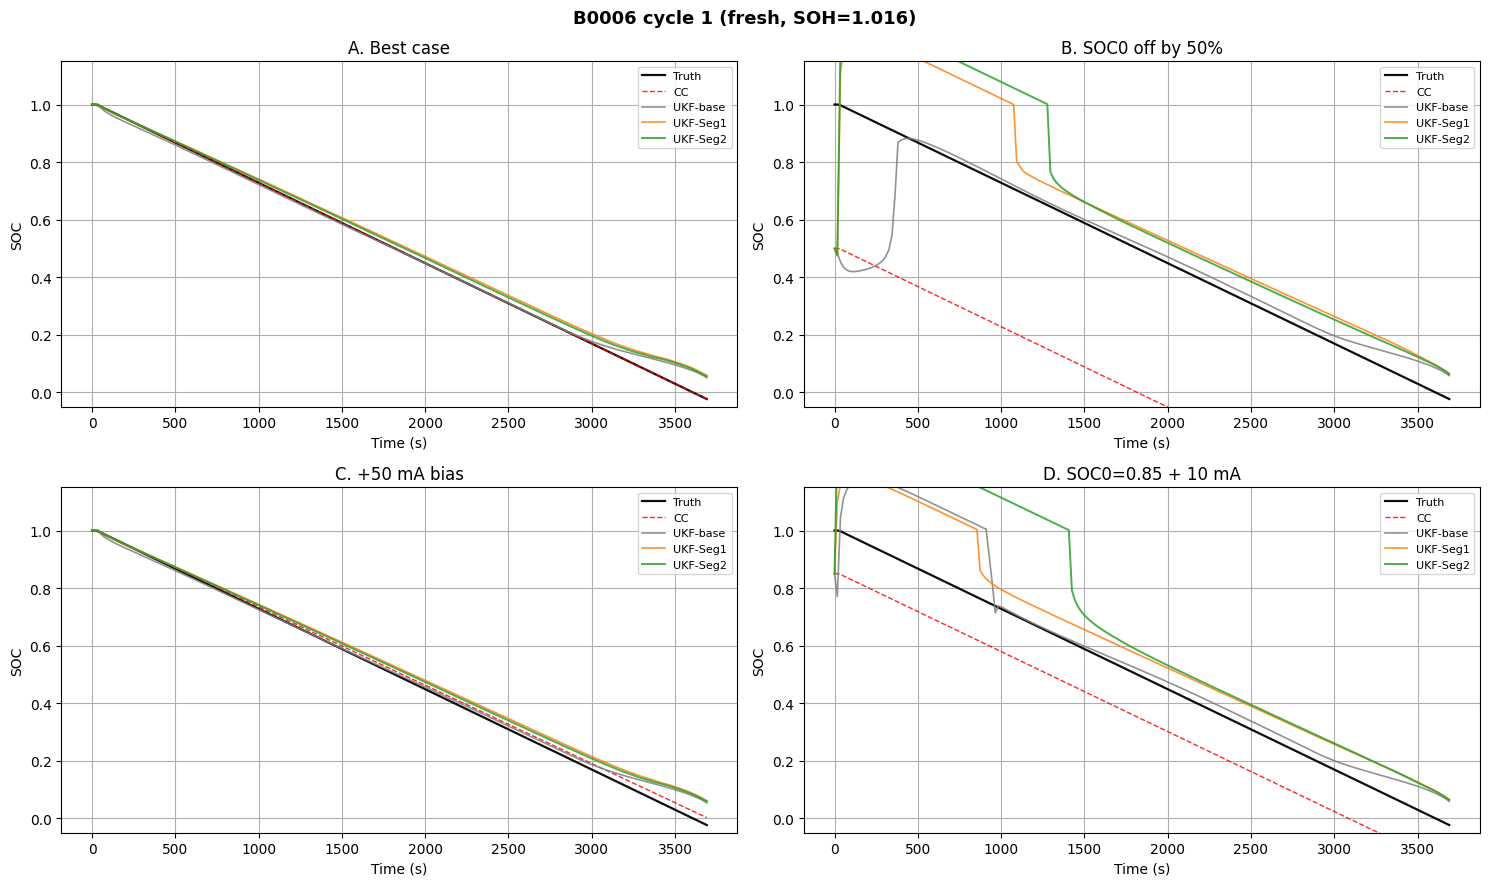

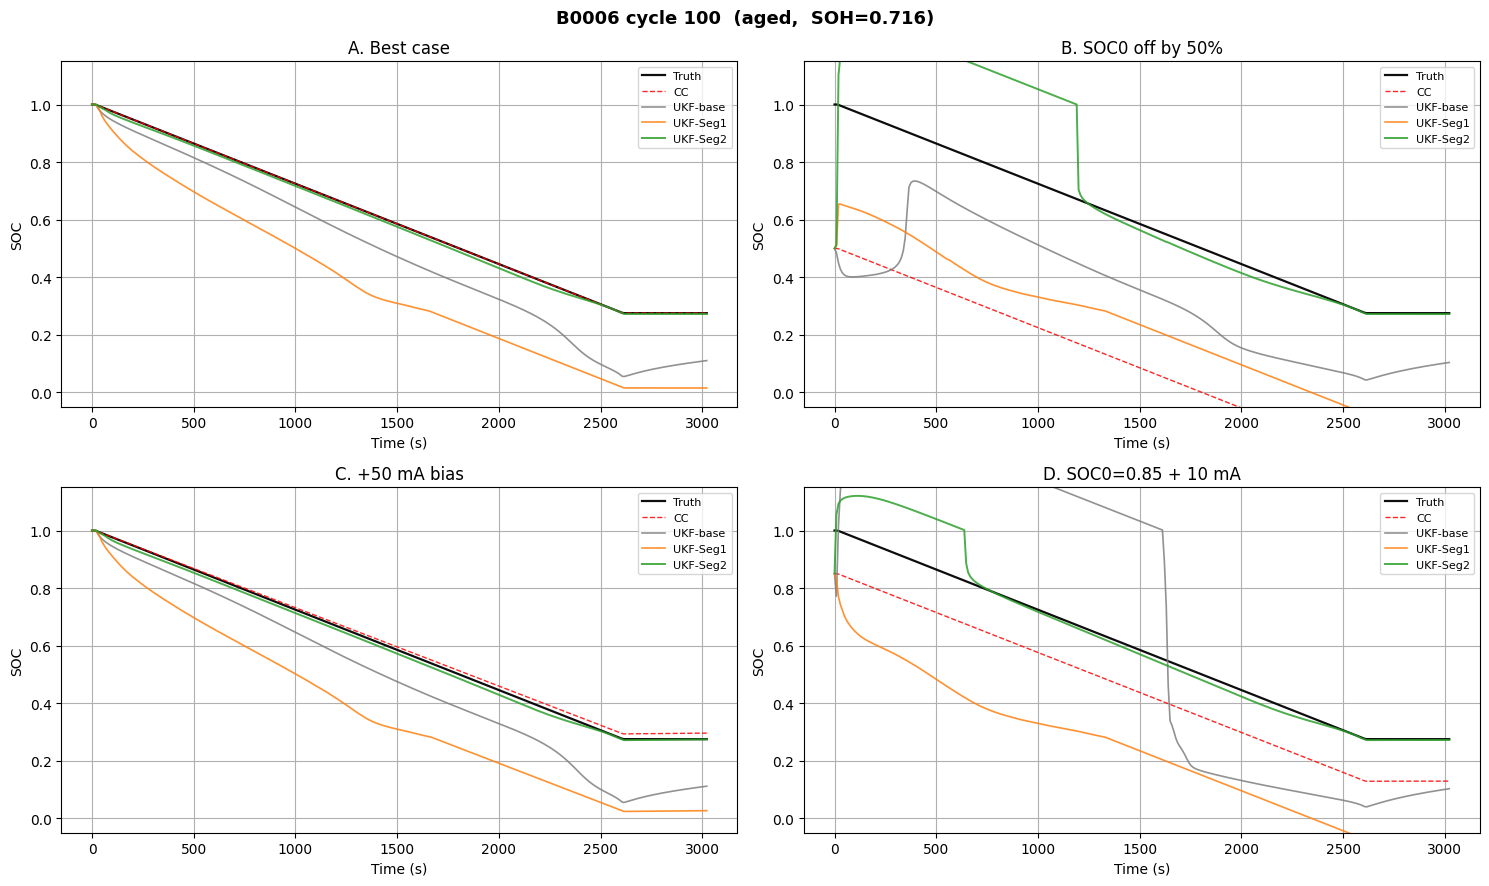

In [15]:
ESTIMATORS = ['CC', 'UKF-base', 'UKF-Seg1', 'UKF-Seg2']
STYLES = {
    'CC':       ('r--', 1.0),
    'UKF-base': ('tab:gray', 1.2),
    'UKF-Seg1': ('tab:orange', 1.2),
    'UKF-Seg2': ('tab:green', 1.4),
}

def plot_scenario_panel(res, suptitle):
    t = res['t']; truth = res['truth']
    fig, axes = plt.subplots(2, 2, figsize=(15, 9))
    for ax, (name, s0, bias) in zip(axes.ravel(), scenarios):
        d = res['scenarios'][name]
        ax.plot(t, truth, 'k-', lw=1.6, alpha=0.95, label='Truth')
        for est in ESTIMATORS:
            color, lw = STYLES[est]
            if isinstance(color, str) and '--' in color:
                ax.plot(t, d[est], color, lw=lw, alpha=0.85, label=est)
            else:
                ax.plot(t, d[est], '-', color=color, lw=lw, alpha=0.85, label=est)
        ax.set_title(f'{name}'); ax.set_xlabel('Time (s)'); ax.set_ylabel('SOC')
        ax.set_ylim(-0.05, 1.15); ax.legend(fontsize=8, loc='best')
    fig.suptitle(suptitle, fontsize=13, fontweight='bold')
    plt.tight_layout(); plt.show()

plot_scenario_panel(res_fresh, f'{VAL_BAT} cycle {FRESH} (fresh, SOH={soh_fresh:.3f})')
plot_scenario_panel(res_aged,  f'{VAL_BAT} cycle {AGED}  (aged,  SOH={soh_aged:.3f})')


In [16]:
def metrics_table(res, title):
    truth = res['truth']
    rows = []
    for name, _, _ in scenarios:
        d = res['scenarios'][name]
        for est in ESTIMATORS:
            rows.append({
                'Scenario': name,
                'Estimator': est,
                'RMSE': rmse(truth, d[est]),
                'MAE': mae(truth, d[est]),
                'final err': d[est][-1] - truth[-1],
            })
    df = pd.DataFrame(rows).round(4)
    print(f'=== {title} ===')
    print(df.pivot(index='Scenario', columns='Estimator', values='RMSE').round(4))
    print()
    return df

df_fresh = metrics_table(res_fresh, f'RMSE table - cycle {FRESH} (SOH={soh_fresh:.3f})')
df_aged  = metrics_table(res_aged,  f'RMSE table - cycle {AGED}  (SOH={soh_aged:.3f})')

=== RMSE table - cycle 1 (SOH=1.016) ===
Estimator                 CC  UKF-Seg1  UKF-Seg2  UKF-base
Scenario                                                  
A. Best case          0.0000    0.0316    0.0278    0.0221
B. SOC0 off by 50%    0.5000    0.1770    0.2183    0.1668
C. +50 mA bias        0.0146    0.0369    0.0328    0.0244
D. SOC0=0.85 + 10 mA  0.1475    0.1303    0.2486    0.1249

=== RMSE table - cycle 100  (SOH=0.716) ===
Estimator                 CC  UKF-Seg1  UKF-Seg2  UKF-base
Scenario                                                  
A. Best case          0.0000    0.2324    0.0092    0.1243
B. SOC0 off by 50%    0.5000    0.3624    0.2027    0.2810
C. +50 mA bias        0.0121    0.2285    0.0119    0.1207
D. SOC0=0.85 + 10 mA  0.1479    0.3603    0.0768    0.3632



### Summary bar chart — RMSE per estimator across all scenarios + cycles

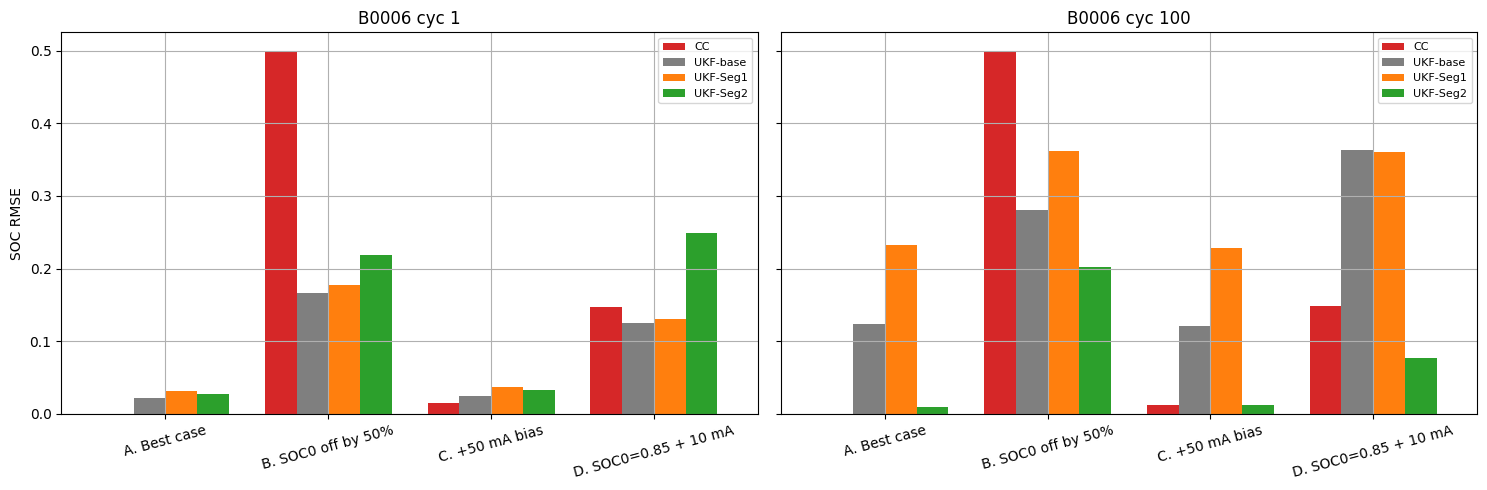

In [17]:
df_all = pd.concat([df_fresh.assign(cycle=f'cyc {FRESH}'), df_aged.assign(cycle=f'cyc {AGED}')])
fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharey=True)
for ax, cyc in zip(axes, df_all['cycle'].unique()):
    sub = df_all[df_all['cycle'] == cyc]
    pivot = sub.pivot(index='Scenario', columns='Estimator', values='RMSE')[ESTIMATORS]
    pivot.plot(kind='bar', ax=ax, width=0.78,
               color=['tab:red', 'tab:gray', 'tab:orange', 'tab:green'])
    ax.set_title(f'{VAL_BAT} {cyc}')
    ax.set_ylabel('SOC RMSE'); ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=15)
    ax.legend(fontsize=8)
plt.tight_layout(); plt.show()


### Cross-cycle scan — RMSE of every estimator on Scenario D, every 10th cycle

Shows how the gap between Seg-3 and the others widens as the cell ages.

In [18]:
scan_cycles = list(range(1, len(disc_val) + 1, 10))
scan_rows = []
for cnum in scan_cycles:
    soh_here = float(disc_val.loc[disc_val['cycle_num'] == cnum, 'SOH_filt'].iloc[0])
    try:
        r = run_all_estimators(VAL_BAT, cnum, soh_here)
    except Exception as e:
        print(f'Skipped cyc {cnum}: {e}'); continue
    truth = r['truth']
    d = r['scenarios']['D. SOC0=0.85 + 10 mA']
    row = {'cycle': cnum, 'SOH': soh_here}
    for est in ESTIMATORS:
        row[est] = rmse(truth, d[est])
    scan_rows.append(row)
scan_df = pd.DataFrame(scan_rows)
scan_df.head()

,cycle,SOH,CC,UKF-base,UKF-Seg1,UKF-Seg2
0,1,1.016057,0.147491,0.124874,0.130320,0.248597
1,11,0.972098,0.147595,0.120980,0.118765,0.233947
2,21,0.969424,0.147581,0.118169,0.118629,0.230477
3,31,0.936607,0.147599,0.198167,0.120588,0.218787
4,41,0.878699,0.147702,0.217505,0.064975,0.092500


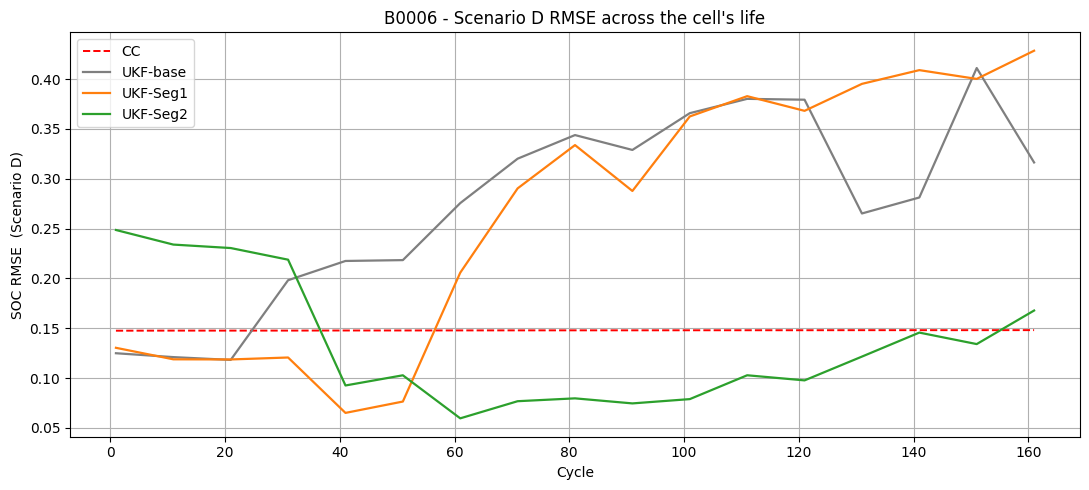

In [19]:
fig, ax = plt.subplots(figsize=(11, 5))
for est in ESTIMATORS:
    color, lw = STYLES[est]
    if est == 'CC':
        ax.plot(scan_df['cycle'], scan_df[est], 'r--', lw=1.4, label=est)
    else:
        ax.plot(scan_df['cycle'], scan_df[est], '-', color=color, lw=1.6, label=est)
ax.set_xlabel('Cycle'); ax.set_ylabel('SOC RMSE  (Scenario D)')
ax.set_title(f'{VAL_BAT} - Scenario D RMSE across the cell\'s life')
ax.legend(); plt.tight_layout(); plt.show()


## Takeaway

* **Seg 1 (SOH-indexed OCV)** — closes the aging gap that the cycle-1-only polynomial leaves open.
* **Seg 2 (LSTM params + V_RC1)** — also fixes the polarisation transient at the start of each cycle.

The cross-cycle scan is the load-bearing chart: the spread between `UKF-base` and `UKF-Seg2` should grow as SOH falls.

(Segment 3 is parked.)